If we look at the distribution of spatial effiency we can there is a clear pattern in the data where there seems to be a section of spatially efficiect homing runs of above 0.9, this suggests that there could be a pattern of interest, e.g is there something different neurally between a spatially efficienct run of >0.9 vs less than that

In [6]:
import pickle
import os

import polars as pl
import matplotlib.pyplot as plt

from behave_analysis.process.session import get_experiment

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may, JAL8_flip3_7may

In [3]:
# The values must be in order of data for the code to work
mice_groups = {
    "JAL6": ['JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_flip2_12mar', 'JAL7_flip5_22mar', 'JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', "JAL8_flip3_7may", 'JAL8_14may'],
    "JAL4": ['JAL4_28aug', 'JAL4_3rdSept', 'JAL4_11thSept', 'JAL4_19thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}

# The experiment objects index must match the session name index for the code to work
experiments_objects = [JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may, JAL8_flip3_7may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

# The session name indexes must match the experiment object indexes
session_names = ["JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept",
                 "JAL5_8thSept", "JAL5_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may", "JAL8_flip3_7may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

Scrape the spatial efficiency numbers across all sessions

In [4]:
spatial_efficiencys = []
for experiment, session_name in zip(experiments_objects, session_names):
        print(f"Loading data for session: {session_name}")
        loaded_session = get_experiment(experiment)

        # Set paths
        base_path = loaded_session.base_path
        processed_path = loaded_session.processed_path
        session_path = os.path.join(base_path, processed_path)
        homing_path = os.path.join(session_path, "homings", "homings_obj.pkl")
        
        try:
            
            with open(homing_path, "rb") as hf:
                homings_object = pickle.load(hf)
                se = homings_object.spatial_efficiency.tolist()
                spatial_efficiencys.extend(se)
                
        except FileNotFoundError:
            print(f"Data not found for session: {session_name}")
            continue

Loading data for session: JAL6_flip3_18mar
Loading data for session: JAL6_flip4_21mar
Loading data for session: JAL6_flip5_25mar
Loading data for session: JAL6_28mar
Loading data for session: JAL3_25aug
Loading data for session: JAL3_1sept
Loading data for session: JAL3_4sept
Loading data for session: JAL3_7sept
Loading data for session: JAL5_8thSept
Loading data for session: JAL5_21stSept
Loading data for session: JAL7_sesh8_9apr
Loading data for session: JAL7_sesh9_16apr
Loading data for session: JAL7_flip5_22mar
Loading data for session: JAL7_flip2_12mar
Loading data for session: JAL7_23apr
Loading data for session: JAL8_flip1_25apr
Loading data for session: JAL8_flip2_29apr
Loading data for session: JAL8_flip4_10may
Loading data for session: JAL8_14may
Loading data for session: JAL8_flip3_7may
Loading data for session: JAL4_3rdSept
Loading data for session: JAL4_19thSept
Loading data for session: JAL4_28aug
Loading data for session: JAL4_11thSept


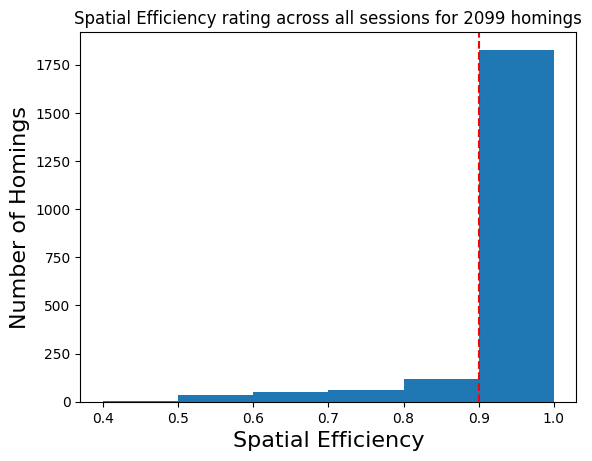

In [20]:
# plot inline
%matplotlib inline
# Plot a histogram of the spatial efficiency
plt.hist(spatial_efficiencys, bins=6)
plt.title(f"Spatial Efficiency rating across all sessions for {len(spatial_efficiencys)} homings")
plt.ylabel("Number of Homings", fontsize=16)
plt.xlabel("Spatial Efficiency", fontsize=16)
plt.axvline(x=0.9, color='r', linestyle='--')
